In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt 

In [2]:
df = pd.read_csv("Salary_dataset.csv")

In [3]:
df.shape

(30, 3)

In [4]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [6]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [8]:
X = df[['YearsExperience']]
y = df['Salary']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
preprocessor = MinMaxScaler()

In [23]:
scaled_X_train = preprocessor.fit_transform(X_train)
scaled_X_test = preprocessor.transform(X_test)

scaled_y_train = preprocessor.fit_transform(y_train.values.reshape(-1, 1)) 
scaled_y_test = preprocessor.transform(y_test.values.reshape(-1, 1))

In [18]:
X_train.shape[1]

1

In [30]:
def batch_gradient_descent(X, y, epochs, learning_rate = 0.01):
    y = y.reshape(-1)
    number_of_features = 2
    w = np.ones(shape=X.shape[1])
    b = 0
    total_samples = X.shape[0]

    cost_list = []
    epoch_list = []

    for i in range(epochs):
        y_pred = np.dot(w , X.T) + b

        w_grad = -(2/total_samples) * (X.T.dot(y-y_pred))
        b_grad = -(2/total_samples) * np.sum(y-y_pred)

        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad

        cost = np.mean(np.square(y-y_pred))

        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)

    return w, b, cost, cost_list, epoch_list


w, b, cost, cost_list, epoch_list = batch_gradient_descent(scaled_X_train, scaled_y_train, 500)
w, b, cost

(array([1.02470381]), -0.013926637660455835, 0.0038261528414680218)

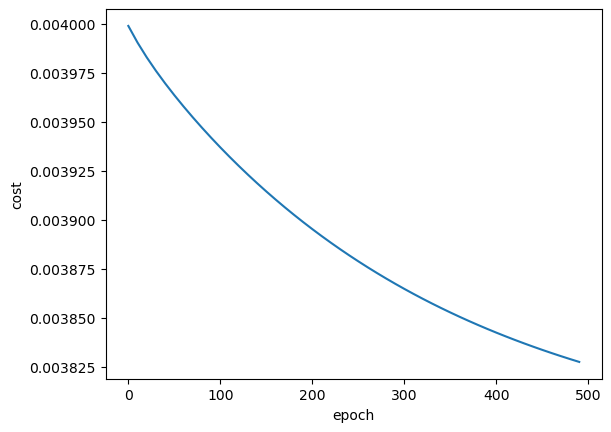

In [31]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list, cost_list)
